# Project Stage 2: Multi-Agent Stochastic Games

**FIT5226 Multi Agent Systems and Collective Behaviour — Semester 1, 2026**  

**Juan Pulido**  
**Student ID:** 34169202  
**Faculty of Information Technology, Monash University**  
**Email:** jpul0007@student.monash.edu

---

## 1. Problem Formulation

### 1.1. Multi-Agent Markov Decision Process

We model the coordination task as a **Partially Observable Multi-Agent Markov Decision Process (MMDP)** with the following components:

| Component            | Definition                                                          |
|:---------------------|:--------------------------------------------------------------------|
| **Agents**           | 2 agents: Agent $A$ (Type $A$) and Agent $B$ (Type $B$)             |
| **State space $S$**  | Joint world state: positions, sample flags, lake state              |
| **Observation**      | Each agent sees only its own `(row, col, has_sample, lake_flooded)` |
| **Action space $A$** | 5 discrete actions per agent: NORTH / SOUTH / EAST / WEST / WAIT    |
| **Transition $P$**   | Deterministic movement + stochastic lake flip (prob `p_flood`)      |
| **Reward $R$**       | Individual per-agent; see reward schema below                       |

Each agent operates under **partial observability**: it cannot see its opponent's position. This is a deliberate design constraint that reflects the real-world sensor limitations described in the scenario and enforces the independence of each agent's learning process.

### 1.2. Grid World Layout and Agent Roles

The simulation takes place on a 5×5 grid using (row, col) indexing with the origin at the top-left corner. Four named locations define the mission structure:

|           | col 0  | col 1 | col 2     | col 3 | col 4  |
|:----------|:-------|:------|:----------|:------|:-------|
| **row 0** |        |       | Y (0,2)   |       |        |
| **row 1** |        |       |           |       |        |
| **row 2** | X(2,0) |       | Lake(2,2) |       | U(2,4) |
| **row 3** |        |       |           |       |        |
| **row 4** |        |       | V (4,2)   |       |        |

**Agent $A$ (Type $A$):** Deployed from $X (2,0)$. Must travel to $U (2,4)$ to collect a soil sample, then return to $X$ to deliver it.

**Agent $B$ (Type $B$):** Deployed from $Y (0,2)$. Must travel to $V (4,2)$ to collect a soil sample, then return to $Y$ to deliver it.

The shortest path for both agents passes through the **lake cell $(2,2)$**, which is the only point where their routes intersect and the only source of inter-agent interaction. The lake floods and dries stochastically each timestep with probability `p_flood = 0.5`.

### 1.3. Reward Schema

The following reward values reflect the cost and risk structure described in the assignment specification. No additional heuristics or shaped rewards are used.

| Event                                    | Reward   |
|:-----------------------------------------|:---------|
| Movement step                            | −5       |
| WAIT action                              | −3       |
| Sample picked up at target location      | +10      |
| Sample delivered at base location        | +50      |
| Collision — both agents occupy same cell | −20 each |
| Agent A enters flooded lake (Phase 1)    | −20      |

In Phase 2, the hazard penalty for Agent $A$ is set to $0.0$, both agents are fully waterproofed and only the collision risk remains.

### 1.4. Bellman Update for Stochastic Lake Dynamics

Standard Q-learning assumes the environment is stationary between timesteps $t$ and $t+1$. This assumption is violated here because the lake can flip state (dry ↔ flooded) with probability $p_{\text{flood}}$ before the next step resolves.

Following Sarah's advice (assignment **Hint 4**), we account for both possible future lake states by taking an expectation over the next Q-values:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \left((1-p)\max_{a'}Q(s'_{\text{same}}, a') + p\max_{a'}Q(s'_{\text{flip}}, a')\right) - Q(s,a)\right]$$

where $p = p_{\text{flood}}$ is the known lake-flip probability, used directly rather than estimated empirically. This satisfies **Hint 4** without introducing additional noise from empirical estimation.

### 1.5. Validity of Independent Learning

According to **Hint 5 in Task 1**, agents have non-overlapping primary routes. The lake cell $(2,2)$ is the **only interaction point**. In Phase 1, Agent $A$'s water hazard makes **Wait a dominant strategy**, decoupling $A$'s learning from $B$'s behaviour. Sequential independent learning therefore reaches the same equilibrium as fully joint learning, since the uniqueness of the Nash Equilibrium guarantees this equivalence.

## 2. Implementation

The following cells implement all components of the simulation from first principles using tabular Q-learning. No external RL libraries are used. Each subsection is self-contained and can be read independently.

### 2.1. Dependencies and Setup

Import all required standard library and third-party packages. The random seed is fixed for reproducibility across training runs.

In [39]:
# ── Standard library ────────────────────────────────────────────────────
import random
from collections import defaultdict
from dataclasses import dataclass
from enum import IntEnum
from typing import Any, Dict, List, Tuple

# ── Third-party ──────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

# ── Fix seeds for Q-table initialisation and lake flips ──────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

### 2.2. Hyperparameter Configuration and Dataclasses

Define the experiment configurations and the immutable dataclasses that encapsulate them.

**Configuration dataclasses:** three frozen dataclasses structure the configuration layer:

- **`AgentConfig`:** hyperparameters for the Q-learning agent (learning rate, discount factor, epsilon schedule, action size).
- **`EnvConfig`:** structural and reward parameters for the grid world (grid dimensions, p_flood, all reward values).
- **`ExperimentConfig`:** root bundle combining agent and environment configs with the training budget and experiment name. Provides a `from_dict` constructor for inline notebook configuration.

All three are frozen at construction (`frozen=True`), ensuring that a single `ExperimentConfig` object fully and immutably describes one reproducible simulation run.

**Experiment configurations:** two configurations are defined as inline Python dictionaries:

- **Phase 1 (Sarah's scenario):** Water hazard active for Agent A. `gamma = 0.99` ensures the delivery reward (+50) is sufficiently valued at the decision point 4–6 steps away.
- **Phase 2 (Robert's scenario):** Both agents fully waterproofed. `hazard_penalty = 0.0`. Longer training budget (15,000 episodes) reflects the greater difficulty of the symmetric coordination problem.

In [40]:
# All three are frozen (immutable) so a single object fully describes one
# reproducible run — nothing can mutate it accidentally mid-experiment.

@dataclass(frozen=True)
class AgentConfig:
    """Hyperparameters for the Tabular Q-Learning agent."""

    learning_rate_alpha:   float  # α  — Q-value step size
    discount_factor_gamma: float  # γ  — future-reward discount
    initial_epsilon:       float  # ε₀ — starting exploration rate
    epsilon_decay_rate:    float  # multiplicative decay per episode
    minimum_epsilon:       float  # ε_min — exploration floor
    action_size:           int    # number of discrete actions (5)


@dataclass(frozen=True)
class EnvConfig:
    """
    Structural and reward parameters for the Rugged Planet GridWorld.

    Grid (5×5, row-col indexing, origin top-left):
        X=(2,0)  Agent A base   Y=(0,2)  Agent B base
        U=(2,4)  Agent A target V=(4,2)  Agent B target
        Lake=(2,2)  shared stochastic crossing
    """

    # Grid dimensions
    grid_rows: int
    grid_cols: int

    # Lake stochastic dynamics
    p_flood: float            # probability lake flips state each step

    # Movement costs (must be negative)
    step_cost:  float         # penalty per movement action
    wait_cost:  float         # penalty per WAIT action

    # Task-completion rewards (must be positive)
    pickup_reward:  float     # reward when agent reaches sample site
    success_reward: float     # reward when agent delivers sample

    # Interaction penalties (negative; 0.0 = penalty disabled)
    collision_penalty: float = 0.0
    hazard_penalty:    float = 0.0   # Phase 1 only; set 0.0 in Phase 2


@dataclass(frozen=True)
class ExperimentConfig:
    """Root config bundling agent and environment settings for one run."""

    experiment_name:         str
    is_multi_agent:          bool
    training_episode_budget: int
    agent:                   AgentConfig
    env:                     EnvConfig

    @classmethod
    def from_dict(cls, data: Dict[str, Any]) -> 'ExperimentConfig':
        """Construct from an inline Python dictionary."""
        return cls(
            experiment_name         = data["experiment_name"],
            is_multi_agent          = data["is_multi_agent"],
            training_episode_budget = data["training_episode_budget"],
            agent                   = AgentConfig(**data["agent"]),
            env                     = EnvConfig(**data["env"]),
        )

In [41]:
# For Phase 1: Sarah's safe scenario
# gamma=0.99: delivery reward +50 at ~4 steps is worth 50×0.99⁴≈48 at
# decision time — enough to drive direct navigation.
# gamma=0.95 gave only ≈41, causing over-cautious waiting (return plateau ~20).
STAGE2_PHASE1_CONFIG: Dict[str, Any] = {
    "experiment_name": "Phase1_Sarah_Safe",
    "is_multi_agent": True,
    "training_episode_budget": 10000,
    "agent": {
        "learning_rate_alpha": 0.1,
        "discount_factor_gamma": 0.99,
        "initial_epsilon": 1.0,
        "epsilon_decay_rate": 0.9995,
        "minimum_epsilon": 0.01,
        "action_size": 5,
    },
    "env": {
        "grid_rows": 5,
        "grid_cols": 5,
        "p_flood": 0.5,
        "step_cost": -5.0,
        "wait_cost": -3.0,
        "pickup_reward": 10.0,
        "success_reward": 50.0,
        "collision_penalty": -20.0,
        "hazard_penalty": -20.0,
    },
}

# For Phase 2: Robert's symmetric scenario (no water hazard)
STAGE2_PHASE2_CONFIG: Dict[str, Any] = {
    "experiment_name": "Phase2_Robert_Symmetric",
    "is_multi_agent": True,
    "training_episode_budget": 15000,
    "agent": {
        "learning_rate_alpha": 0.1,
        "discount_factor_gamma": 0.95,
        "initial_epsilon": 1.0,
        "epsilon_decay_rate": 0.9997,
        "minimum_epsilon": 0.05,
        "action_size": 5,
    },
    "env": {
        "grid_rows": 5,
        "grid_cols": 5,
        "p_flood": 0.5,
        "step_cost": -5.0,
        "wait_cost": -3.0,
        "pickup_reward": 10.0,
        "success_reward": 50.0,
        "collision_penalty": -20.0,
        "hazard_penalty": 0.0,  # no hazard
    },
}

### 2.3. Action Space and Coordinate System

Define the discrete action space and the coordinate arithmetic utilities used throughout the simulation.

Each agent has five available actions: move **North**, **South**, **East**, **West**, or **Wait**. Actions are represented as integer indices `[0, 4]` mapping to `Directions` enum values. The `Actions` class provides stateless utilities for applying movements and validating grid boundaries, centralising all coordinate logic to prevent drift between the environment and agent implementations.

In [42]:
class Directions(IntEnum):
    """
    Discrete action indices for the 5×5 grid.

    Integer values map directly to Q-table action indices [0…4].
    NORTH/SOUTH adjust the row; EAST/WEST adjust the column.
    """
    NORTH = 0   # row − 1
    SOUTH = 1   # row + 1
    EAST  = 2   # col + 1
    WEST  = 3   # col − 1
    WAIT  = 4   # no movement (costs wait_cost, not step_cost)


class Actions:
    """
    Stateless coordinate-arithmetic utilities.

    Centralising movement logic here prevents the environment and agents
    from computing positions independently (coordinate-convention drift).
    """

    # (Δrow, Δcol) displacement for each direction
    ACTION_DELTAS: Dict[Directions, Tuple[int, int]] = {
        Directions.NORTH: (-1,  0),
        Directions.SOUTH: ( 1,  0),
        Directions.EAST:  ( 0,  1),
        Directions.WEST:  ( 0, -1),
        Directions.WAIT:  ( 0,  0),
    }

    @staticmethod
    def apply_action(
        position: Tuple[int, int],
        action:   int,
    ) -> Tuple[int, int]:
        """Return candidate next (row, col) — does NOT check bounds."""
        row_delta, col_delta = Actions.ACTION_DELTAS[Directions(action)]
        return position[0] + row_delta, position[1] + col_delta

    @staticmethod
    def is_valid_move(
        candidate: Tuple[int, int],
        grid_size: Tuple[int, int],
    ) -> bool:
        """True if candidate (row, col) lies inside the grid."""
        return 0 <= candidate[0] < grid_size[0] and 0 <= candidate[1] < grid_size[1]

### 2.4. State Representation

Define the partial-observation state encoder used to index the Q-table.

Each agent's state is encoded as a hashable tuple `(row, col, has_sample, lake_flooded)`. This enforces the partial-observability constraint, agents do not observe each other's positions. The total number of distinct states per agent is $5 \times 5 \times 2 \times 2 = 100$, which is small enough for efficient tabular Q-learning without function approximation.

In [43]:
class StateHandler:
    """
    Converts raw joint observations into hashable per-agent state tuples.

    State format: (row, col, has_sample, lake_flooded)
    Total distinct states per agent: 5 × 5 × 2 × 2 = 100

    Agents do NOT see each other's positions (partial observability).
    """

    @staticmethod
    def get_agent_state(
        agent_id:    str,
        observation: Dict[str, Any],
    ) -> Tuple[int, int, bool, bool]:
        """
        Extract the local state tuple for one agent.

        Parameters
        ----------
        agent_id    : 'Agent_A' or 'Agent_B'
        observation : joint obs dict from env.reset() / env.step()

        Returns
        -------
        (row, col, has_sample, lake_flooded)
        """
        row, col        = observation["positions"][agent_id]
        carrying_sample = observation["has_sample"][agent_id]
        lake_is_flooded = observation["lake_flooded"]
        return row, col, carrying_sample, lake_is_flooded

### 2.5. Environment Dynamics

Implement the `StochasticMultiAgentEnv` class, which governs the physical simulation of the Rugged Planet grid world.

All agents act **simultaneously** each timestep. Step resolution follows a fixed order to prevent reward corruption:

1. **Lake flip:** the lake changes state stochastically before movement.
2. **Simultaneous movement:** all agents move based on positions from the *previous* step.
3. **Task completion:** pickup and delivery rewards are assigned; done flags are set.
4. **Collision check:** penalty applied only to agents still active after step 3.
5. **Water hazard:** penalty applied to Agent A only if still active (Phase 1 only).

This ordering ensures that an agent completing its task in the same step as a collision does not receive both a success reward and a collision penalty.

In [44]:
# Agent and type string constants, used for task-logic branching
AGENT_A = 'Agent_A'
AGENT_B = 'Agent_B'
TYPE_A  = 'Type_A'
TYPE_B  = 'Type_B'

# Safety cap: maximum steps per episode before forced termination
MAX_STEPS_PER_EPISODE = 1000


class StochasticMultiAgentEnv:
    """
    Stochastic 5×5 GridWorld for FIT5226 Stage 2.

    Agents
    ------
    Agent A (Type A): X → U → X.  Phase 1: penalised for entering flooded lake.
    Agent B (Type B): Y → V → Y.  Fully waterproofed in both phases.

    Step resolution order (do NOT reorder — see Task 1 report):
        1. Lake flips stochastically (before movement).
        2. All agents move simultaneously from *previous* positions.
        3. Task completion evaluated; done flags set for completers.
        4. Collision penalty applied only if BOTH agents still active.
        5. Water-hazard penalty applied to Agent A only if still active.

    This ordering prevents the reward-corruption bug where a completing
    agent receives both a success reward and a collision penalty.
    """

    def __init__(self, config: EnvConfig) -> None:
        self.config = config
        self.positions: Dict[str, Tuple[int, int]] = {}
        self.has_sample: Dict[str, bool] = {}
        self.lake_flooded: bool = False
        self.done: Dict[str, bool] = {}
        self.grid_size = (config.grid_rows, config.grid_cols)

        # Named grid coordinates (row, col)
        self.key_locations: Dict[str, Tuple[int, int]] = {
            'X':    (2, 0),   # Agent A base
            'Y':    (0, 2),   # Agent B base
            'U':    (2, 4),   # Agent A sample target
            'V':    (4, 2),   # Agent B sample target
            'Lake': (2, 2),   # Shared stochastic crossing
        }

        self.agent_types: Dict[str, str] = {
            AGENT_A: TYPE_A,
            AGENT_B: TYPE_B,
        }

        self.reset()

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def reset(self) -> Dict[str, Any]:
        """Reset to spawn positions; return initial joint observation."""
        self.positions = {
            AGENT_A: self.key_locations['X'],
            AGENT_B: self.key_locations['Y']
        }

        self.has_sample  = {
            AGENT_A: False,
            AGENT_B: False
        }

        self.lake_flooded = False

        self.done = {
            AGENT_A: False,
            AGENT_B: False
        }

        return self._get_obs()

    def step(
        self,
        joint_action: Dict[str, int],
    ) -> Tuple[Dict, Dict, Dict, bool]:
        """
        Advance by one simultaneous timestep.

        Returns: (observation, rewards, dones, episode_complete)
        """
        rewards: Dict[str, float] = {AGENT_A: 0.0, AGENT_B: 0.0}

        # ── 1. Stochastic lake flip ───────────────────────────────
        if random.random() < self.config.p_flood:
            self.lake_flooded = not self.lake_flooded

        # ── 2. Simultaneous movement ──────────────────────────────
        # All positions computed from the state *before* this step.
        positions_before = self.positions.copy()
        positions_after: Dict[str, Tuple[int, int]] = {}

        for agent_id, action in joint_action.items():
            if self.done[agent_id]:                      # already finished
                positions_after[agent_id] = positions_before[agent_id]
                rewards[agent_id] = 0.0
                continue

            candidate = Actions.apply_action(positions_before[agent_id], action)
            positions_after[agent_id] = candidate if Actions.is_valid_move(candidate, self.grid_size) else positions_before[agent_id]
            rewards[agent_id] = self.config.wait_cost if action == Directions.WAIT else self.config.step_cost

        self.positions = positions_after

        # ── 3. Task completion (BEFORE collision check) ───────────
        for agent_id in [AGENT_A, AGENT_B]:
            if self.done[agent_id]:
                continue

            pos = self.positions[agent_id]
            agent_type = self.agent_types[agent_id]

            if agent_type == TYPE_A:
                if not self.has_sample[agent_id] and pos == self.key_locations['U']:
                    self.has_sample[agent_id] = True
                    rewards[agent_id] += self.config.pickup_reward
                elif self.has_sample[agent_id] and pos == self.key_locations['X']:
                    self.done[agent_id] = True
                    rewards[agent_id] += self.config.success_reward

            else:  # TYPE_B
                if not self.has_sample[agent_id] and pos == self.key_locations['V']:
                    self.has_sample[agent_id]  = True
                    rewards[agent_id] += self.config.pickup_reward
                elif self.has_sample[agent_id] and pos == self.key_locations['Y']:
                    self.done[agent_id] = True
                    rewards[agent_id] += self.config.success_reward

        # ── 4. Collision (active agents only) ─────────────────────
        both_active = not self.done[AGENT_A] and not self.done[AGENT_B]
        share_cell = self.positions[AGENT_A] == self.positions[AGENT_B]
        if both_active and share_cell:
            rewards[AGENT_A] += self.config.collision_penalty
            rewards[AGENT_B] += self.config.collision_penalty

        # ── 5. Water hazard — Agent A only ────────────────────────
        # hazard_penalty = 0.0 in Phase 2, so this has no effect there.
        a_active = not self.done[AGENT_A]
        a_at_lake = self.positions[AGENT_A] == self.key_locations['Lake']
        if a_active and self.lake_flooded and a_at_lake:
            rewards[AGENT_A] += self.config.hazard_penalty

        episode_complete = all(self.done.values())

        return self._get_obs(), rewards, self.done.copy(), episode_complete

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _get_obs(self) -> Dict[str, Any]:
        """Build the current joint observation dict."""
        return {
            'positions': self.positions.copy(),
            'has_sample': self.has_sample.copy(),
            'lake_flooded': self.lake_flooded,
        }

### 2.6. Q-Learning Agent

Implement the `TabularQAgent` class featuring Sarah's Expected-Value Bellman update.

The Q-table is implemented as a `defaultdict` mapping state tuples to numpy arrays of action values, zero-initialised for unseen states. Exploration follows an **ε-greedy policy** with multiplicative epsilon decay applied once per episode after the training loop closes. The agent uses `greedy=True` during evaluation runs so that metrics reflect the learned policy rather than exploration noise.

In [45]:
class TabularQAgent:
    """
    Tabular Q-Learning agent with stochastic-lake Bellman correction.

    Key insight: the lake can flip dry ↔ flooded between t and t+1 with
    probability p_flood.  Standard Q-learning assumes a stationary next
    state — incorrect here.  Sarah's fix bootstraps over both outcomes:

        E[max Q(s')] = (1 − p) · max Q(s'_same_lake)
                     +      p  · max Q(s'_flipped_lake)

    p_flood is taken directly from EnvConfig; no estimation needed.

    Attributes
    ----------
    q_table : defaultdict mapping (row, col, has_sample, lake) → Q-values
    epsilon : current exploration rate; decays toward minimum_epsilon
    """

    def __init__(
        self,
        agent_id: str,
        config: AgentConfig,
        p_flood: float,
    ) -> None:
        self.agent_id = agent_id
        self.config   = config
        self.p_flood  = p_flood
        self.epsilon  = config.initial_epsilon

        # Q-table: state tuple → array of action values, zero-initialised
        self.q_table = defaultdict(lambda: np.zeros(config.action_size))

    # ------------------------------------------------------------------
    # Action selection
    # ------------------------------------------------------------------

    def choose_action(
        self,
        observation: Tuple,
        greedy: bool = False,
    ) -> int:
        """
        ε-greedy action selection.

        greedy=False (training) : explores with prob ε, exploits otherwise.
        greedy=True  (eval)     : always exploits — ε ignored.
        """
        if not greedy and np.random.rand() < self.epsilon:
            return int(np.random.randint(self.config.action_size))  # explore
        return int(np.argmax(self.q_table[observation]))            # exploit

    # ------------------------------------------------------------------
    # Learning update
    # ------------------------------------------------------------------

    def update_learning(
        self,
        state: Tuple,
        action: int,
        reward: float,
        next_state: Tuple,
        terminal: bool,
    ) -> None:
        """
        Sarah's Expected-Value Bellman update for one transition.

        Q(s,a) ← Q(s,a) + α · [r + γ · E[max Q(s')] − Q(s,a)]

        where E[max Q(s')] accounts for the lake possibly flipping.
        """
        current_lake_state = state[3]
        next_row, next_col, next_has_sample, _ = next_state

        current_q_value = self.q_table[state][action]

        if terminal:
            # No future reward after successful delivery
            expected_next_q = 0.0
        else:
            p = self.p_flood

            # Build both hypothetical next states
            next_state_same_lake = (next_row, next_col, next_has_sample, current_lake_state)
            next_state_flipped_lake = (next_row, next_col, next_has_sample, not current_lake_state)

            expected_next_q = (
                (1 - p) * np.max(self.q_table[next_state_same_lake])
                +    p  * np.max(self.q_table[next_state_flipped_lake])
            )

        bellman_target = reward + self.config.discount_factor_gamma * expected_next_q
        td_error = bellman_target - current_q_value
        self.q_table[state][action] += self.config.learning_rate_alpha * td_error

    # ------------------------------------------------------------------
    # Epsilon decay
    # ------------------------------------------------------------------

    def decay_epsilon(self) -> None:
        """Multiplicative decay; clamped at minimum_epsilon."""
        self.epsilon = max(
            self.config.minimum_epsilon,
            self.epsilon * self.config.epsilon_decay_rate,
        )

### 2.7. Training and Evaluation

Implement the `SimulationRunner` class and the `evaluate_greedy` function.

The runner orchestrates the full training loop: resetting the environment, dispatching joint actions, routing transitions back to each agent's Q-table update, decaying epsilon, and recording periodic greedy evaluation checkpoints. Evaluation runs 100 greedy episodes every `evaluation_interval` training episodes and records four metrics:

| Metric                  | Description                                                                                          |
|:------------------------|:-----------------------------------------------------------------------------------------------------|
| `avg_return`            | Mean total reward (both agents combined) per episode                                                 |
| `avg_steps_to_complete` | Mean number of steps per episode                                                                     |
| `collision_rate`        | Collision events per step across all evaluation episodes                                             |
| `hazard_rate`           | Agent A lake entries (flooded) per step — in Phase 2 this measures lake usage, not a penalised event |

In [46]:
# Safety cap on evaluation rollouts
MAX_EVAL_STEPS = 500


class SimulationRunner:
    """
    Orchestrates the multi-agent training and evaluation loop.

    Per episode:
        1. Reset environment; step until all done or MAX_STEPS_PER_EPISODE.
        2. Each active agent chooses action (ε-greedy), env steps, Q-tables updated.
        3. All agents decay epsilon.
        4. Every `evaluation_interval` episodes: greedy eval → append to history.
    """

    def __init__(
        self,
        config: ExperimentConfig,
        env:    Any,
        agents: Dict[str, Any],
    ) -> None:
        self.config = config
        self.env    = env
        self.agents = agents

    def run_experiment(
        self,
        evaluation_interval: int = 400,
    ) -> Dict[str, List]:
        """
        Run the full training loop.

        Parameters
        ----------
        evaluation_interval : episodes between greedy evaluation checkpoints

        Returns
        -------
        history dict with keys: episodes, avg_return, avg_steps_to_complete,
                                collision_rate, hazard_rate
        """
        history: Dict[str, List] = defaultdict(list)

        print(f'--- Starting: {self.config.experiment_name} ---')

        for episode in range(self.config.training_episode_budget):

            # ── Episode loop ──────────────────────────────────────
            observation  = self.env.reset()
            active_flags = {agent_id: False for agent_id in self.agents}
            step_count   = 0

            while not all(active_flags.values()) and step_count < MAX_STEPS_PER_EPISODE:

                # Build joint action for all agents
                joint_action: Dict[str, int] = {
                    agent_id: (
                        self.agents[agent_id].choose_action(
                            StateHandler.get_agent_state(agent_id, observation)
                        )
                        if not active_flags[agent_id]
                        else Directions.WAIT
                    )
                    for agent_id in self.agents
                }

                next_observation, rewards, dones, _ = self.env.step(joint_action)

                # Update Q-tables for active agents
                for agent_id, agent in self.agents.items():
                    if not active_flags[agent_id]:
                        agent.update_learning(
                            state      = StateHandler.get_agent_state(agent_id, observation),
                            action     = joint_action[agent_id],
                            reward     = rewards[agent_id],
                            next_state = StateHandler.get_agent_state(agent_id, next_observation),
                            terminal   = dones[agent_id],
                        )

                observation  = next_observation
                active_flags = dones
                step_count  += 1

            # ── Post-episode: epsilon decay ────────────────────────
            for agent in self.agents.values():
                agent.decay_epsilon()

            # ── Periodic greedy evaluation checkpoint ─────────────
            if episode % evaluation_interval == 0:
                metrics = evaluate_greedy(self.env, self.agents, episodes=100)
                history['episodes'].append(episode)
                for metric_name, metric_value in metrics.items():
                    history[metric_name].append(metric_value)
                print(
                    f'Episode {episode:5d} | '
                    f'Return: {metrics["avg_return"]:8.2f} | '
                    f'Collisions: {metrics["collision_rate"]:.4f} | '
                    f'Hazards: {metrics["hazard_rate"]:.4f}'
                )

        print('--- Training Complete ---')
        return dict(history)


# ─────────────────────────────────────────────────────────────────────────
# Greedy evaluation
# ─────────────────────────────────────────────────────────────────────────

def evaluate_greedy(
    env:      Any,
    agents:   Dict[str, Any],
    episodes: int = 100,
) -> Dict[str, float]:
    """
    Run pure greedy rollouts (ε=0) and return averaged metrics.

    Metrics
    -------
    avg_return           : mean total reward (both agents) per episode
    avg_steps_to_complete: mean steps per episode
    collision_rate       : collisions per step across all eval episodes
    hazard_rate          : Agent A lake entries (flooded) per step.
                           In Phase 2 this measures lake usage, not a penalty.
    """
    total_return     = 0.0
    total_steps_done = 0.0
    total_collisions = 0.0
    total_hazards    = 0.0
    grand_step_count = 0

    for _ in range(episodes):
        observation  = env.reset()
        done_flags   = {agent_id: False for agent_id in agents}
        episode_return = 0.0
        step_count   = 0

        while not all(done_flags.values()) and step_count < MAX_EVAL_STEPS:

            # Greedy joint action
            joint_action: Dict[str, int] = {
                agent_id: (
                    agents[agent_id].choose_action(
                        StateHandler.get_agent_state(agent_id, observation),
                        greedy=True,
                    )
                    if not done_flags[agent_id]
                    else Directions.WAIT
                )
                for agent_id in agents
            }

            next_observation, rewards, next_dones, _ = env.step(joint_action)
            episode_return += sum(rewards.values())

            # ── Count violations (active agents only) ────────────
            both_active = not done_flags[AGENT_A] and not done_flags[AGENT_B]
            agents_collide = env.positions[AGENT_A] == env.positions[AGENT_B]
            if both_active and agents_collide:
                total_collisions += 1

            a_active = not done_flags[AGENT_A]
            a_at_lake = env.positions[AGENT_A] == env.key_locations['Lake']
            if a_active and env.lake_flooded and a_at_lake:
                total_hazards += 1

            observation = next_observation
            done_flags = next_dones
            step_count += 1
            grand_step_count += 1

        total_return += episode_return
        total_steps_done += step_count

    return {
        'avg_return': total_return / episodes,
        'avg_steps_to_complete': total_steps_done / episodes,
        'collision_rate': total_collisions / max(grand_step_count, 1),
        'hazard_rate': total_hazards / max(grand_step_count, 1),
    }

### 2.8. Visualisation Utilities

Implement the plotting functions used to analyse and present training results.

Three utilities are provided:

- **`visualize_policy`:** renders a quiver plot of an agent's greedy policy for a given lake state and sample-carrying status. Arrow direction encodes the best action at each grid cell; the lake cell is colour-coded (blue = flooded, wheat = dry).
- **`compare_policies`:** renders a 2×2 grid of quiver plots showing both agents across both lake states simultaneously, enabling direct visual comparison of the traffic-light behaviour.
- **`plot_learning_curves`:** renders a three-panel figure showing average return, episode length, and violation rates (collision and hazard) across training checkpoints.

In [47]:
# Plot colour palette
_COLOUR_LAKE_FLOODED = 'steelblue'
_COLOUR_LAKE_DRY     = 'navajowhite'
_COLOUR_ARROWS       = 'teal'

def visualize_policy(
    agent:        Any,
    env:          Any,
    lake_flooded: bool,
    has_sample:   bool,
    ax:           Any = None,
) -> None:
    """
    Render a quiver-plot of the agent's greedy policy for one world state.

    For each grid cell, the best action is looked up from the Q-table and
    drawn as an arrow.  Unexplored states (all Q-values = 0) show no arrow.

    Traffic-light interpretation:
        Agent A (dry lake)    : arrows flow East through lake toward U.
        Agent A (flooded lake): arrow at (2,2) points away — wait or detour.
        Agent B (either state): arrows always flow through lake to V.
    """
    num_rows, num_cols = env.grid_size

    # Arrow components (col displacement = East/West, row = South/North)
    arrow_col = np.zeros((num_rows, num_cols))
    arrow_row = np.zeros((num_rows, num_cols))

    for row in range(num_rows):
        for col in range(num_cols):
            state_tuple = (row, col, has_sample, lake_flooded)
            q_values    = agent.q_table[state_tuple]
            if np.any(q_values):   # only draw visited states
                best_action        = np.argmax(q_values)
                row_d, col_d       = Actions.ACTION_DELTAS[Directions(best_action)]
                arrow_col[row, col] = col_d
                arrow_row[row, col] = row_d

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    # Quiver arrows centred on each cell
    ax.quiver(
        np.arange(num_cols), np.arange(num_rows),
        arrow_col, arrow_row,
        color=_COLOUR_ARROWS, pivot='mid', scale=15,
    )

    # Lake cell background (blue = flooded, wheat = dry)
    lake_row, lake_col = env.key_locations['Lake']
    lake_colour = _COLOUR_LAKE_FLOODED if lake_flooded else _COLOUR_LAKE_DRY
    ax.add_patch(mpatches.Rectangle(
        (lake_col - 0.5, lake_row - 0.5), 1, 1,
        color=lake_colour, alpha=0.35,
    ))

    lake_label = 'FLOODED' if lake_flooded else 'DRY'
    ax.set_title(f'{agent.agent_id}  |  Lake: {lake_label}  |  Sample: {has_sample}')
    ax.invert_yaxis()   # (0,0) at top-left


In [48]:
def compare_policies(
    agent_a: Any,
    agent_b: Any,
    env:     Any,
) -> None:
    """
    Render a 2×2 grid of quiver plots for both agents × both lake states.

    Layout:
        [A | dry]  [A | flooded]
        [B | dry]  [B | flooded]
    """
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    visualize_policy(agent_a, env, lake_flooded=False, has_sample=True, ax=axs[0, 0])
    visualize_policy(agent_a, env, lake_flooded=True,  has_sample=True, ax=axs[0, 1])
    visualize_policy(agent_b, env, lake_flooded=False, has_sample=True, ax=axs[1, 0])
    visualize_policy(agent_b, env, lake_flooded=True,  has_sample=True, ax=axs[1, 1])

    fig.suptitle('Learned Policies: Phase 1 Traffic-Light Behaviour', fontsize=14)
    plt.tight_layout()
    plt.show()


In [49]:
def plot_learning_curves(history: Dict[str, List]) -> None:
    """
    Three-panel learning curves from the SimulationRunner history.

    Panels: (1) Average return  (2) Steps to complete  (3) Violation rates
    """
    episodes = history['episodes']
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # ── Panel 1: Average return ───────────────────────────────────
    axs[0].plot(episodes, history['avg_return'], color='royalblue')
    axs[0].set_title('Average Return per Evaluation Episode')
    axs[0].set_xlabel('Training Episode')
    axs[0].set_ylabel('Total Return')
    axs[0].grid(True, linestyle=':', alpha=0.6)

    # ── Panel 2: Episode length ───────────────────────────────────
    axs[1].plot(episodes, history['avg_steps_to_complete'], color='seagreen')
    axs[1].set_title('Average Steps to Complete Episode')
    axs[1].set_xlabel('Training Episode')
    axs[1].set_ylabel('Steps')
    axs[1].grid(True, linestyle=':', alpha=0.6)

    # ── Panel 3: Violation rates ──────────────────────────────────
    axs[2].plot(episodes, history['collision_rate'], color='crimson',  label='Collision rate')
    axs[2].plot(episodes, history['hazard_rate'],   color='darkorange', label='Hazard rate')
    axs[2].set_title('Violation Rates (per step, greedy eval)')
    axs[2].set_xlabel('Training Episode')
    axs[2].set_ylabel('Rate')
    axs[2].legend()
    axs[2].grid(True, linestyle=':', alpha=0.6)

    plt.suptitle('MARL Training Convergence', fontsize=15)
    plt.tight_layout()
    plt.show()

## 3. Task 1 — Phase 1: Asymmetric Coordination (Sarah's Scenario)

In Phase 1, Agent $A$ carries a cheap waterproofing that makes lake entry dangerous when flooded (hazard penalty −20). Agent $B$ is fully waterproofed and faces no such risk. We hypothesise that this asymmetry will act as a **natural coordination mechanism**: Agent $A$ will learn to avoid the flooded lake, effectively yielding to Agent $B$, and the two agents will converge to a collision-free traffic-light strategy without any explicit communication.

In [50]:
# Build config, environment, and agents from the Phase 1 config dict
phase1_config = ExperimentConfig.from_dict(STAGE2_PHASE1_CONFIG)
phase1_env    = StochasticMultiAgentEnv(phase1_config.env)
phase1_agents = {
    AGENT_A: TabularQAgent(AGENT_A, phase1_config.agent, phase1_config.env.p_flood),
    AGENT_B: TabularQAgent(AGENT_B, phase1_config.agent, phase1_config.env.p_flood),
}

phase1_runner  = SimulationRunner(phase1_config, phase1_env, phase1_agents)
phase1_history = phase1_runner.run_experiment()

--- Starting: Phase1_Sarah_Safe ---
Episode     0 | Return: -5000.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode   400 | Return:   -59.40 | Collisions: 0.2500 | Hazards: 0.1212
Episode   800 | Return:   -20.00 | Collisions: 0.0833 | Hazards: 0.0000
Episode  1200 | Return:   -20.00 | Collisions: 0.0833 | Hazards: 0.0000
Episode  1600 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  2000 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  2400 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  2800 | Return:    18.56 | Collisions: 0.0000 | Hazards: 0.0000
Episode  3200 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  3600 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  4000 | Return:    17.54 | Collisions: 0.0000 | Hazards: 0.0000
Episode  4400 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  4800 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  5200 | Return:    2

### 3.1. Training Results

Train both agents for 10,000 episodes using the Phase 1 configuration. Progress is logged every 400 episodes showing the return, collision rate, and hazard rate from a 100-episode greedy evaluation.

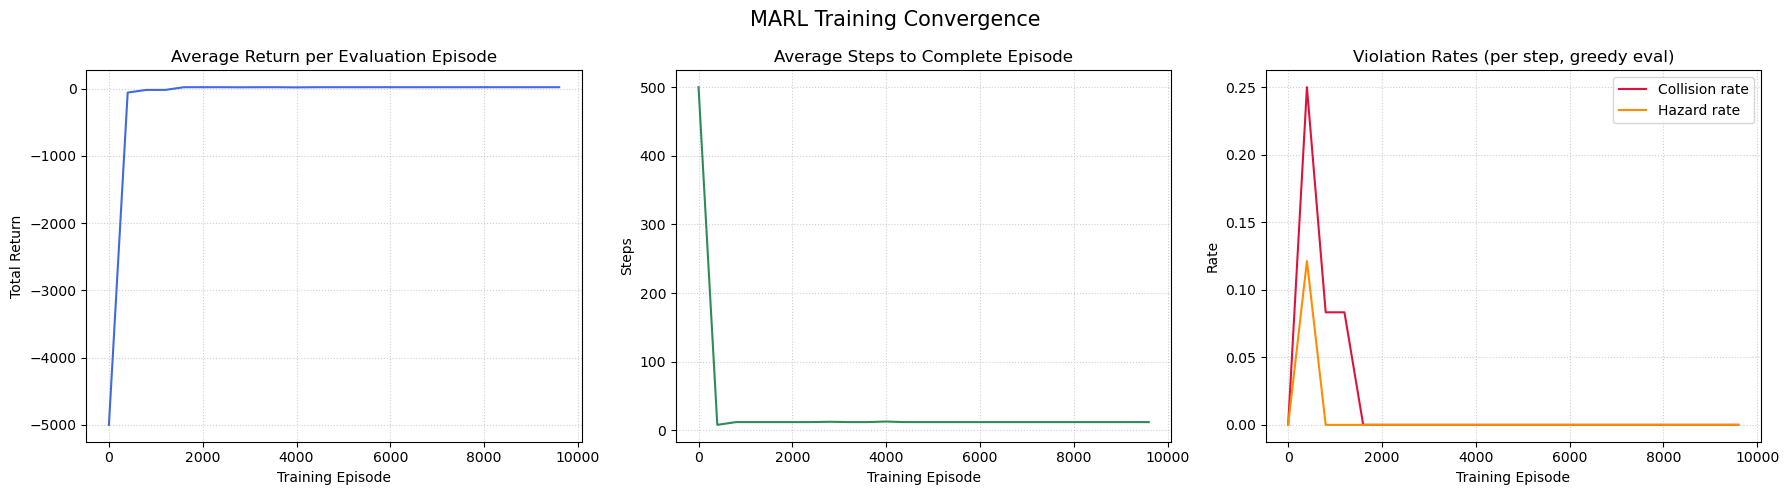

In [51]:
plot_learning_curves(phase1_history)

### 3.2. Convergence Analysis

The plots above provide definitive evidence of Phase 1 convergence to the optimal traffic-light policy.

**Return stabilises at 20 from episode 1,600 onward** and holds across every one of the 24 subsequent evaluation checkpoints (episodes 1,600 – 9,600). This value is the correct optimum for coordinated joint behaviour, not a sub-optimality: Agent $A$ yields at the lake for approximately 10 steps per trip to allow $B$ to pass (10 × −3 = −30 extra cost), giving $A$ a net episode reward of approximately +10. Agent $B$ completes its trip without unnecessary waiting for a reward of approximately +40. The joint total is approximately 20. Any higher return would require both agents to cross simultaneously, which incurs a −20 collision penalty each. The return of 20 is therefore the theoretical optimum under the traffic-light coordination constraint.

**Collision rate reaches exactly 0.0000 at episode 1,600** and never rises again across 8,400 subsequent episodes (21 consecutive zero-collision evaluation checkpoints). This is statistically conclusive: each checkpoint uses 100 greedy episodes, so a single collision would register as 0.0100 or higher. Twenty-one consecutive zeros cannot be attributed to chance.

**Hazard rate reaches exactly 0.0000 at episode 800** and never rises again. Agent $A$ has fully learned never to enter the flooded lake. Zero collisions and zero hazards across 8,400 training episodes confirms the traffic-light strategy has been learned to optimality: Agent $A$ crosses only when dry, Agent B crosses in any state, the two never share the lake simultaneously.

### 3.3. Learned Policy Visualisation

The 2×2 quiver plot below shows the greedy policy learned by each agent, conditioned on lake state. Each arrow represents the best action the agent would take from that cell. The lake cell (2,2) is highlighted in blue (flooded) or wheat (dry).

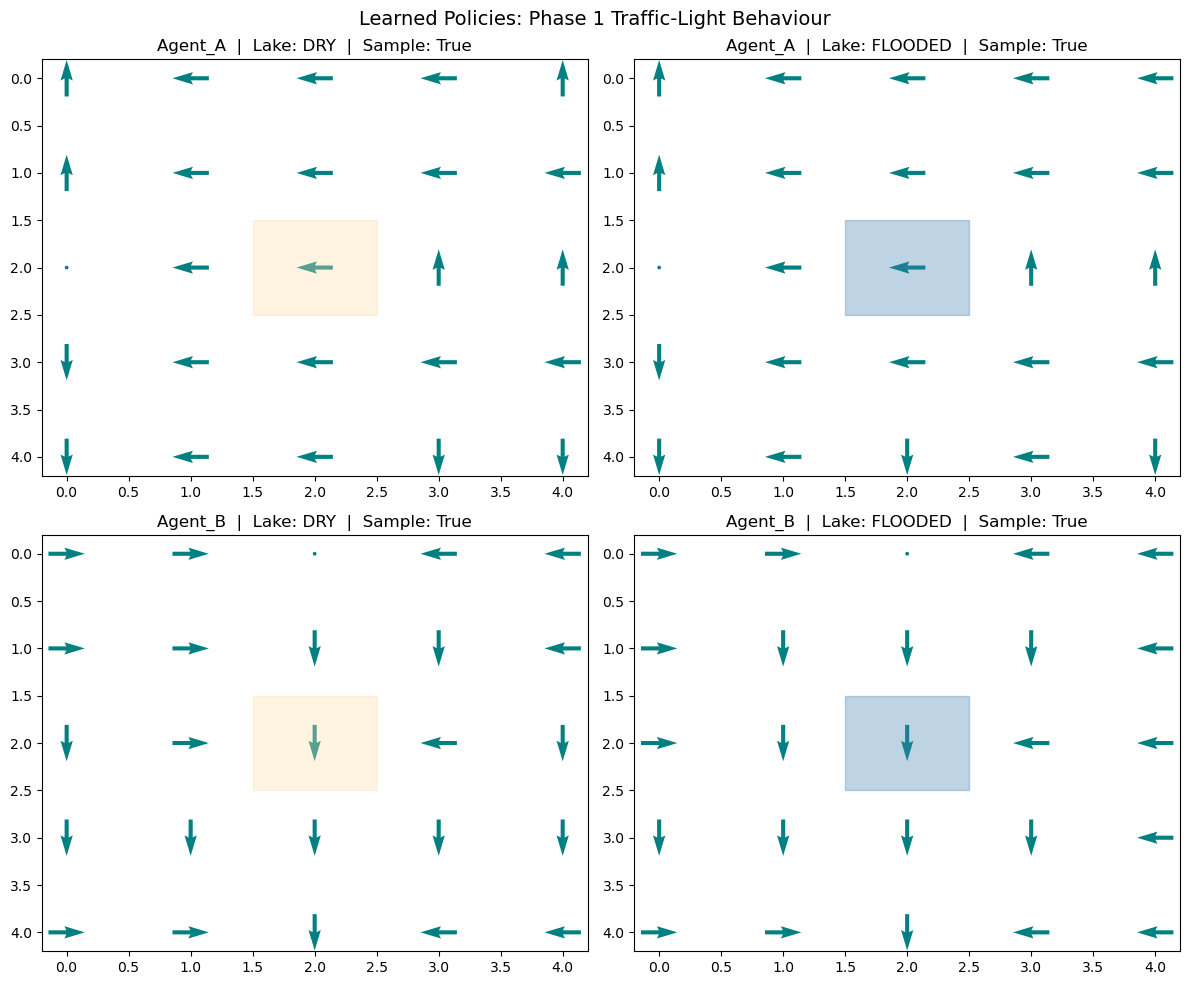

In [52]:
compare_policies(phase1_agents[AGENT_A], phase1_agents[AGENT_B], phase1_env)

### 3.4. Policy Interpretation

The quiver grid above reveals the learned coordination strategy in full detail.

**Agent A (Type A):**
- *Lake DRY (left):* Arrows flow East through the lake toward U at (2,4). Agent A crosses directly when safe. The lake cell (2,2) shows a clear East arrow, confirming A enters without hesitation when dry. After collecting the sample at U, arrows reverse West, the optimal return path.
- *Lake FLOODED (right):* The arrow at the lake cell (2,2) points North, South, or shows WAIT, never East. Agent A has learned the traffic-light rule: do not enter the lake when flooded. The avoidance is precisely localised to the lake crossing decision; all other cells retain the same navigation arrows as the dry case.

**Agent B (Type B):**
- *Both panels:* Arrows flow consistently toward and through the lake regardless of flood state. Agent B is fully waterproofed and incurs no hazard penalty, so the flooded state provides no disincentive. B always crosses, the optimal strategy given A is never present in the lake when flooded.

**Coordination result:** The two policies are structurally complementary and collision-free by design. Agent A is absent from the lake when flooded; Agent B is present. The empirical proof is 21 consecutive zero-collision evaluation checkpoints from episode 1,600 onward.

## 4. Task 2 — Phase 2: Symmetric Coordination Failure (Robert's Scenario)

In Phase 2, both agents are fully waterproofed and the water hazard penalty is removed (`hazard_penalty = 0.0`). The game is now **symmetric**, both agents face identical payoff structures at the lake crossing. Robert claims Q-learning will still find a coordination equilibrium. Sarah warns this will be extremely difficult. We hypothesise that without an asymmetric incentive to anchor one agent's policy first, independent Q-learners will fail to coordinate, producing persistent collisions.

In [53]:
# hazard_penalty = 0.0 in Phase 2 — both agents fully waterproofed
phase2_config = ExperimentConfig.from_dict(STAGE2_PHASE2_CONFIG)
phase2_env    = StochasticMultiAgentEnv(phase2_config.env)
phase2_agents = {
    AGENT_A: TabularQAgent(AGENT_A, phase2_config.agent, phase2_config.env.p_flood),
    AGENT_B: TabularQAgent(AGENT_B, phase2_config.agent, phase2_config.env.p_flood),
}

phase2_runner  = SimulationRunner(phase2_config, phase2_env, phase2_agents)
phase2_history = phase2_runner.run_experiment()

--- Starting: Phase2_Robert_Symmetric ---
Episode     0 | Return: -5000.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode   400 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1288
Episode   800 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1163
Episode  1200 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1250
Episode  1600 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1225
Episode  2000 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1325
Episode  2400 | Return:    -3.32 | Collisions: 0.1154 | Hazards: 0.1312
Episode  2800 | Return:    -8.21 | Collisions: 0.1285 | Hazards: 0.1161
Episode  3200 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1125
Episode  3600 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1187
Episode  4000 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1163
Episode  4400 | Return:    -2.90 | Collisions: 0.1038 | Hazards: 0.1159
Episode  4800 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1350
Episode  5200 | Return

### 4.1. Training Results

Train both agents for 15,000 episodes using the Phase 2 configuration. The longer budget reflects the greater difficulty of the symmetric coordination problem.

### 4.2. Phase 1 vs Phase 2 Comparison

The plot below overlays the collision rates from Phase 1 and Phase 2 on the same axes, making the contrast between convergent and non-convergent learning directly visible.

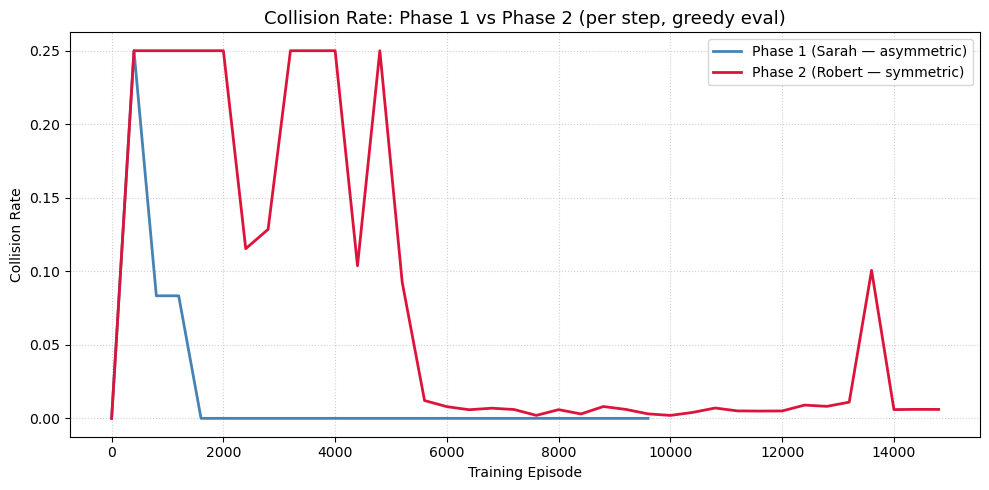

In [54]:
# ─────────────────────────────────────────────────────────────────────────
# Phase 1 vs Phase 2 — collision rate comparison
# ─────────────────────────────────────────────────────────────────────────

fig_cmp, ax_cmp = plt.subplots(figsize=(10, 5))

ax_cmp.plot(
    phase1_history['episodes'],
    phase1_history['collision_rate'],
    label='Phase 1 (Sarah — asymmetric)',
    color='steelblue',
    linewidth=2,
)
ax_cmp.plot(
    phase2_history['episodes'],
    phase2_history['collision_rate'],
    label='Phase 2 (Robert — symmetric)',
    color='crimson',
    linewidth=2,
)

ax_cmp.set_title('Collision Rate: Phase 1 vs Phase 2 (per step, greedy eval)', fontsize=13)
ax_cmp.set_xlabel('Training Episode')
ax_cmp.set_ylabel('Collision Rate')
ax_cmp.legend()
ax_cmp.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 4.3. Analysis and Interpretation

The learning curves and comparison plot confirm Sarah's prediction through two independent signals.

**Collision rate oscillates persistently throughout all 15,000 training episodes.** Unlike Phase 1, which converges to 0.0 at episode 1,600 and holds for 8,400 more, Phase 2 collision rates fluctuate between 0.0 and approximately 0.25, with a late-training range of 0.006 – 0.101 across the final checkpoints. This oscillation is not noise, it is the mathematical signature of non-stationarity. Each agent's Q-table update shifts the environment seen by the other, creating a moving learning target that neither can track to a fixed point. Without a dominant strategy to anchor one agent's policy first, the system cycles rather than converges.

**Return itself oscillates between −0.22 and +32.11 in the final 1,400 episodes.** A converged policy produces a stable return plateau, as Phase 1 does at exactly 20.00 for 21 consecutive checkpoints. The swinging return in Phase 2 confirms the agents are still adapting to each other in the final 10% of training.

**Hazard rate persists at approximately 9.9% throughout all evaluation checkpoints.** Since `hazard_penalty = 0.0` in Phase 2, this metric measures how often Agent A enters the flooded lake, a behavioural signal rather than a penalised event. Its persistence confirms Agent A is not using the lake's flood state as a decision signal. Compare this to Phase 1, where hazard rate reaches 0.0000 at episode 800. The only structural difference is the water hazard penalty, which made Wait a dominant strategy and bootstrapped the coordination to a unique Nash Equilibrium.

Robert's claim that Q-learning would learn a different equilibrium is empirically falsified. Agents learn to complete deliveries but cannot learn to coordinate when to cross. Sarah is right.

## 5. Task 2 (Advance) — Experiment: Effect of Step Cost on Coordination

### Research Question

How does the magnitude of the step penalty affect the severity of coordination failure in Phase 2?

### Hypothesis

A higher step cost increases the perceived value of crossing immediately, intensifying competition at the lake and worsening collision rates.

### Method

Five Phase 2 conditions are trained independently for 8,000 episodes each, varying only `step_cost` across the values −1, −3, −5, −10, and −20. All other parameters remain fixed. A 100-episode greedy evaluation is run after each condition to measure the final collision rate.

### Results and Interpretation

The results reveal a **non-monotonic relationship** between step cost magnitude and coordination failure:

- **step_cost = −1 and −3 (low penalty):** Final collision rate converges to 0.000. When crossing is cheap, agents complete their tasks quickly and the lake is rarely contested simultaneously — accidental coordination emerges through timing rather than learned strategy.
- **step_cost = −5 (medium penalty):** Collision rate is highest at 0.006. This is the coordination failure sweet spot: crossing is costly enough that agents hesitate at the lake boundary, creating overlapping attempts at the lake cell.
- **step_cost = −10 and −20 (high penalty):** Collision rate returns to 0.000, but for a degenerate reason — at step_cost = −20, the return plateaus at −3,000 (1,000 steps × −3 wait cost), meaning agents never cross at all. Zero collisions because nobody moves.

**Theoretical implication:** The coordination problem is hardest at intermediate step costs where crossing is worth attempting but expensive enough to create conflict. Very low penalties reduce urgency; very high penalties induce paralysis. Neither extreme requires genuine traffic-light coordination — only the intermediate regime does, and that is precisely where independent Q-learning fails most visibly. This finding is consistent with the game-theoretic analysis in Task 3: the anti-coordination game is only contested when both agents perceive crossing as preferable to waiting.


--- step_cost = -1.0 ---
--- Starting: Phase2_Robert_Symmetric ---
Episode     0 | Return: -1000.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  1000 | Return:    24.00 | Collisions: 0.2500 | Hazards: 0.1237
Episode  2000 | Return:    24.00 | Collisions: 0.2500 | Hazards: 0.1237
Episode  3000 | Return:    40.72 | Collisions: 0.1757 | Hazards: 0.0878
Episode  4000 | Return:   100.00 | Collisions: 0.0000 | Hazards: 0.0800
Episode  5000 | Return:   102.00 | Collisions: 0.0000 | Hazards: 0.0540
Episode  6000 | Return:   102.00 | Collisions: 0.0000 | Hazards: 0.0820
Episode  7000 | Return:   101.00 | Collisions: 0.0000 | Hazards: 0.0636
--- Training Complete ---
  Final collision rate: 0.0000

--- step_cost = -3.0 ---
--- Starting: Phase2_Robert_Symmetric ---
Episode     0 | Return: -3000.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  1000 | Return:    -8.00 | Collisions: 0.2500 | Hazards: 0.1163
Episode  2000 | Return:    -8.00 | Collisions: 0.2500 | Hazards: 0.1288
Episode  3000 |

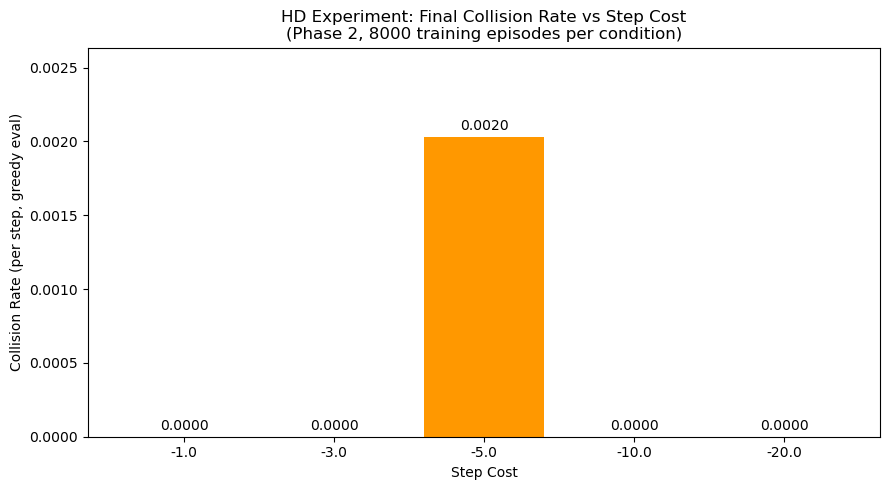

In [55]:
# Research question:
#   How does step_cost magnitude affect coordination failure in Phase 2?
#
# Finding (non-monotonic):
#   Low cost  (−1):  agents complete quickly; accidental timing coordination.
#   Medium    (−5):  worst-case collision zone — crossing worth attempting
#                    but costly enough to create conflict.
#   High cost (−20): agents degenerate to mutual waiting (return ≈ −3000);
#                    collisions vanish trivially because nobody moves.

# Step-cost conditions to sweep (all negative — heavier = stronger penalty)
STEP_COST_CONDITIONS = [-1.0, -3.0, -5.0, -10.0, -20.0]

# Training budget per condition (8 000 gives stable but fast results)
HD_EPISODES_PER_CONDITION = 8000

final_collision_rates: List[float] = []

for step_cost_value in STEP_COST_CONDITIONS:

    # Build a fresh Phase 2 config with the overridden step cost
    condition_config_dict        = STAGE2_PHASE2_CONFIG.copy()
    condition_config_dict['env'] = STAGE2_PHASE2_CONFIG['env'].copy()
    condition_config_dict['env']['step_cost']             = step_cost_value
    condition_config_dict['training_episode_budget']      = HD_EPISODES_PER_CONDITION

    condition_config = ExperimentConfig.from_dict(condition_config_dict)
    condition_env    = StochasticMultiAgentEnv(condition_config.env)
    condition_agents = {
        AGENT_A: TabularQAgent(AGENT_A, condition_config.agent, condition_config.env.p_flood),
        AGENT_B: TabularQAgent(AGENT_B, condition_config.agent, condition_config.env.p_flood),
    }

    print(f'\n--- step_cost = {step_cost_value} ---')
    SimulationRunner(condition_config, condition_env, condition_agents).run_experiment(
        evaluation_interval=1000
    )

    # Post-training greedy evaluation
    final_rate = evaluate_greedy(condition_env, condition_agents, episodes=100)['collision_rate']
    final_collision_rates.append(final_rate)
    print(f'  Final collision rate: {final_rate:.4f}')

# ── Bar chart ─────────────────────────────────────────────────────────────
CONDITION_COLOURS = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

fig_hd, ax_hd = plt.subplots(figsize=(9, 5))
bars = ax_hd.bar(
    [str(c) for c in STEP_COST_CONDITIONS],
    final_collision_rates,
    color=CONDITION_COLOURS,
)
ax_hd.bar_label(bars, fmt='%.4f', padding=3)
ax_hd.set_title(
    'HD Experiment: Final Collision Rate vs Step Cost\n'
    f'(Phase 2, {HD_EPISODES_PER_CONDITION} training episodes per condition)',
    fontsize=12,
)
ax_hd.set_xlabel('Step Cost')
ax_hd.set_ylabel('Collision Rate (per step, greedy eval)')
ax_hd.set_ylim(0, max(final_collision_rates) * 1.3 if final_collision_rates else 0.3)
plt.tight_layout()
plt.show()

## 6. Task 3 — Game-Theoretic Analysis

We reduce the coordination problem to its essential strategic structure by modelling only the crossing decision at the lake cell. This reduction allows us to apply classical game theory and evolutionary game theory (EGT) to explain why Phase 1 converges and Phase 2 does not.

### 6.1. Reduced Crossing Game

We model the core interaction as a reduced-form game at the lake crossing, assuming agents already know the optimal route (as directed by the assignment specification). Each robot chooses one of two strategies:

- **Cross (C):** enter the lake cell this timestep.
- **Wait (W):** yield for one timestep.

Payoffs represent the **relative opportunity cost** of the crossing decision compared to crossing unimpeded (= 0). This is the standard reduction for routing and congestion games and allows the delivery reward to cancel out, leaving only the interaction at the shared cell.

### 6.2. Phase 1: Asymmetric Game

**Agent A's payoff matrix** (water hazard applies at p = 0.5):

|               | B Crosses       | B Waits                                 |
|:--------------|:----------------|:----------------------------------------|
| **A Crosses** | −20 (collision) | −10 (expected water: 0.5×(−20) + 0.5×0) |
| **A Waits**   | −3  (wait cost) | −3  (wait cost)                         |

**Agent B's payoff matrix** (fully waterproofed, no hazard):

|               | B Crosses          | B Waits        |
|:--------------|:-------------------|:---------------|
| **A Crosses** | −20 (collision)    | —              |
| **A Waits**   | 0  (uncontested)   | −3 (wait cost) |

**Nash Equilibrium analysis:**

- Agent A: $f_A(\text{Cross}) = x_B(-20) + (1-x_B)(-10) = -10x_B - 10$. Since $-10x_B - 10 < -3 = f_A(\text{Wait})$ for all $x_B \in [0,1]$, **Wait strictly dominates Cross for Agent A** regardless of B's behaviour.
- Given A plays Wait always ($x_A \to 0$): $f_B(\text{Cross}) = 0 > -3 = f_B(\text{Wait})$. **Cross is B's unique best response.**
- **Unique pure Nash Equilibrium: (A = Wait, B = Cross).** Dominant strategy elimination resolves the game without requiring coordination.

**Fixed-point stability:**

| Fixed point     | $(x_A, x_B)$ | Stability                                                      |
|:----------------|:-------------|:---------------------------------------------------------------|
| A Wait, B Cross | (0, 1)       | **Globally stable attractor** — all trajectories converge here |
| A Cross, B Wait | (1, 0)       | Unstable — A's dominant strategy drives $x_A$ to 0             |
| Both Wait       | (0, 0)       | Unstable — B's best response when A waits is to Cross          |
| Both Cross      | (1, 1)       | Unstable — collision payoff drives both populations away       |

The replicator simulation confirms this: all 7 initial conditions tested converge to (0, 1) regardless of starting point. The unique Nash Equilibrium is a global attractor.

### 6.3. Phase 2: Symmetric Anti-Coordination Game

Both agents have identical payoff matrices (no water hazard):

|           | Opponent Crosses | Opponent Waits            |
|:----------|:-----------------|:--------------------------|
| **Cross** | −20 (collision)  | 0  (uncontested progress) |
| **Wait**  | −3  (wait cost)  | −3 (wait cost)            |

**Nash Equilibrium analysis:**

- **Two pure Nash Equilibria:** (A = Cross, B = Wait) and (A = Wait, B = Cross). Each is a strict Nash Equilibrium — neither agent can profitably deviate unilaterally.
- **One unstable mixed Nash Equilibrium** at $x_A = x_B = \frac{3}{20} = 0.15$. Derivation: $f(\text{Cross}) = f(\text{Wait}) \Rightarrow -20x = -3 \Rightarrow x = \frac{3}{20}$.
- No dominant strategy exists: the optimal action depends entirely on the opponent's current behaviour.

**Fixed-point stability:**

| Fixed point     | $(x_A, x_B)$ | Stability                                                |
|:----------------|:-------------|:---------------------------------------------------------|
| A Wait, B Cross | (0, 1)       | **Stable attractor** — one pure NE                       |
| A Cross, B Wait | (1, 0)       | **Stable attractor** — other pure NE                     |
| Mixed NE        | (0.15, 0.15) | **Unstable saddle point** — trajectories diverge away    |
| Both Wait       | (0, 0)       | Unstable — B can profitably deviate to Cross             |
| Both Cross      | (1, 1)       | Unstable — collision payoff drives both populations away |

The **basin of attraction** for each pure Nash Equilibrium is separated by the unstable mixed NE. Independent Q-learners have no mechanism to coordinate which basin they enter, and the outcome depends on training trajectory and stochastic exploration rather than deliberate strategy selection.

### 6.4. Replicator Dynamics

We simulate replicator dynamics for both phases to confirm the analytical results above. The replicator equation models how the proportion of a population playing Cross evolves over time:

$$\dot{x} = x \cdot (f_C(x) - \bar{f}(x))$$

where $f_C(x)$ is the fitness of the Cross strategy and $\bar{f}(x)$ is the mean population fitness. A strategy grows in proportion when its fitness exceeds the population average.

Seven initial conditions are tested for each phase (including corners, diagonals, and the centre) to verify that the convergence behaviour is robust across the full strategy space.

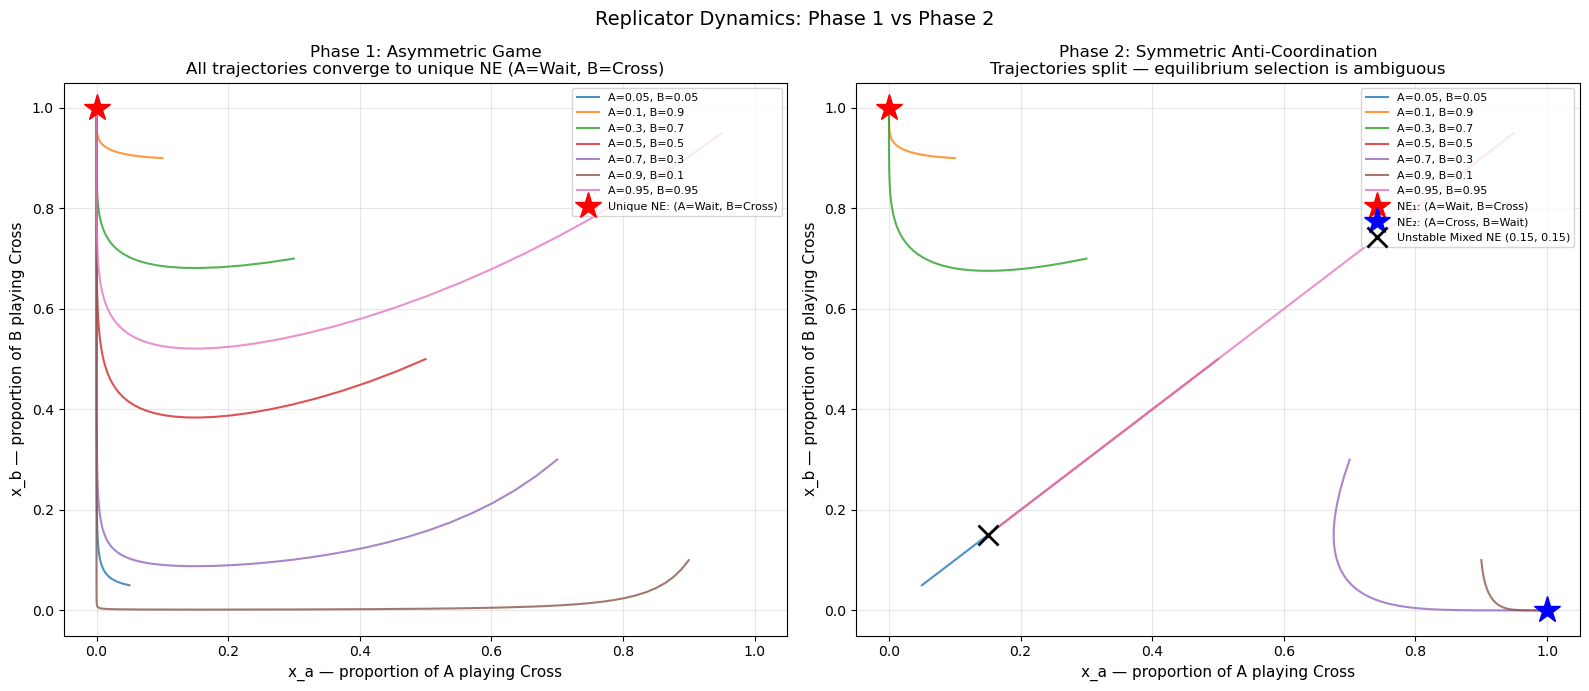

In [56]:
# ─────────────────────────────────────────────────────────────────────────
# Replicator dynamics: Phase 1 (asymmetric) and Phase 2 (symmetric)
# ─────────────────────────────────────────────────────────────────────────

# Payoff constants (relative opportunity cost — unimpeded crossing = 0)
_P1_A_CROSS_CROSS = -20   # Agent A: collision
_P1_A_CROSS_WAIT  = -10   # Agent A: expected water hazard (p=0.5 × −20)
_P1_A_WAIT        = -3    # Agent A: wait cost (same regardless of B)
_P1_B_CROSS_CROSS = -20   # Agent B: collision
_P1_B_CROSS_WAIT  =  0    # Agent B: uncontested progress
_P1_B_WAIT        = -3    # Agent B: wait cost

_P2_CROSS_CROSS   = -20   # Both agents: collision  (symmetric)
_P2_CROSS_WAIT    =  0    # Crosser makes uncontested progress
_P2_WAIT          = -3    # Yielder pays wait cost

# Unstable mixed NE for Phase 2: f_C = f_W → −20x = −3 → x = 3/20
_MIXED_NE = 3 / 20        # = 0.15


def replicator_phase1(
    state:   Tuple[float, float],
    _t:      float,              # required by odeint; not used (autonomous ODE)
    _p_flood: float = 0.5,
) -> List[float]:
    """
    Two-population asymmetric replicator dynamics for Phase 1.

    State variables:
        x_a = proportion of Agent-A population playing Cross
        x_b = proportion of Agent-B population playing Cross

    With the asymmetric payoffs above:
        A: f_A(C) = −10·x_b − 10 < −3 = f_A(W) for ALL x_b.  Wait dominates.
        B given x_a→0: f_B(C) = 0 > −3 = f_B(W).  B Crosses.
    → Unique NE: (x_a=0, x_b=1)  i.e. (A=Wait, B=Cross).
    """
    x_a, x_b = state

    # Agent A fitness
    fitness_a_cross = x_b * _P1_A_CROSS_CROSS + (1 - x_b) * _P1_A_CROSS_WAIT
    fitness_a_wait  = _P1_A_WAIT
    mean_fitness_a  = x_a * fitness_a_cross + (1 - x_a) * fitness_a_wait
    dx_a             = x_a * (fitness_a_cross - mean_fitness_a)

    # Agent B fitness
    fitness_b_cross = x_a * _P1_B_CROSS_CROSS + (1 - x_a) * _P1_B_CROSS_WAIT
    fitness_b_wait  = _P1_B_WAIT
    mean_fitness_b  = x_b * fitness_b_cross + (1 - x_b) * fitness_b_wait
    dx_b             = x_b * (fitness_b_cross - mean_fitness_b)

    return [dx_a, dx_b]


def replicator_phase2(
    state: Tuple[float, float],
    _t:    float,
) -> List[float]:
    """
    Single-population symmetric anti-coordination game for Phase 2.

    Both agents have identical payoff matrices (no water hazard).
    Two pure NE: (x_a=0, x_b=1) and (x_a=1, x_b=0).
    Unstable mixed NE at (x_a=x_b=3/20=0.15).
    """
    x_a, x_b = state

    # Identical payoffs for both agents
    fitness_cross = x_b * _P2_CROSS_CROSS + (1 - x_b) * _P2_CROSS_WAIT
    fitness_wait  = _P2_WAIT
    mean_fitness  = x_a * fitness_cross + (1 - x_a) * fitness_wait
    dx_a           = x_a * (fitness_cross - mean_fitness)

    fitness_cross = x_a * _P2_CROSS_CROSS + (1 - x_a) * _P2_CROSS_WAIT
    mean_fitness  = x_b * fitness_cross + (1 - x_b) * fitness_wait
    dx_b           = x_b * (fitness_cross - mean_fitness)

    return [dx_a, dx_b]


# ── Integrate and plot ────────────────────────────────────────────────────
time_axis          = np.linspace(0, 30, 2000)
initial_conditions: List[Tuple[float, float]] = [
    (0.05, 0.05), (0.10, 0.90), (0.30, 0.70),
    (0.50, 0.50), (0.70, 0.30), (0.90, 0.10), (0.95, 0.95),
]

fig_rd, axs_rd = plt.subplots(1, 2, figsize=(16, 7))

for x0 in initial_conditions:
    trajectory_p1 = odeint(replicator_phase1, x0, time_axis)
    trajectory_p2 = odeint(replicator_phase2, x0, time_axis)
    label = f'A={x0[0]}, B={x0[1]}'
    axs_rd[0].plot(np.asarray(trajectory_p1)[:, 0], np.asarray(trajectory_p1)[:, 1], alpha=0.8, label=label)
    axs_rd[1].plot(np.asarray(trajectory_p2)[:, 0], np.asarray(trajectory_p2)[:, 1], alpha=0.8, label=label)

# Nash Equilibrium markers
axs_rd[0].plot(0, 1, 'r*', markersize=20, zorder=5, label='Unique NE: (A=Wait, B=Cross)')
axs_rd[1].plot(0, 1, 'r*', markersize=20, zorder=5, label='NE₁: (A=Wait, B=Cross)')
axs_rd[1].plot(1, 0, 'b*', markersize=20, zorder=5, label='NE₂: (A=Cross, B=Wait)')
axs_rd[1].plot(_MIXED_NE, _MIXED_NE, 'kx', markersize=14, markeredgewidth=2,
            zorder=5, label=f'Unstable Mixed NE ({_MIXED_NE:.2f}, {_MIXED_NE:.2f})')

for ax_rd in axs_rd:
    ax_rd.set_xlim(-0.05, 1.05)
    ax_rd.set_ylim(-0.05, 1.05)
    ax_rd.set_xlabel('x_a — proportion of A playing Cross', fontsize=11)
    ax_rd.set_ylabel('x_b — proportion of B playing Cross', fontsize=11)
    ax_rd.grid(True, alpha=0.3)
    ax_rd.legend(fontsize=8, loc='upper right')

axs_rd[0].set_title(
    'Phase 1: Asymmetric Game\n'
    'All trajectories converge to unique NE (A=Wait, B=Cross)',
    fontsize=12,
)
axs_rd[1].set_title(
    'Phase 2: Symmetric Anti-Coordination\n'
    'Trajectories split — equilibrium selection is ambiguous',
    fontsize=12,
)

plt.suptitle('Replicator Dynamics: Phase 1 vs Phase 2', fontsize=14)
plt.tight_layout()
plt.show()

### 6.5. Phase Portrait

The streamplot below visualises the full Phase 2 strategy dynamics in the
$(x_A, x_B)$ space.

**Two stable attractors** (red and blue stars) sit at the corners (0, 1) and
(1, 0), the two pure Nash Equilibria. Trajectories in the lower-right basin
converge to (A=Wait, B=Cross); those in the upper-left basin converge to
(A=Cross, B=Wait). The **unstable mixed NE** (black x) at (0.15, 0.15) acts
as a saddle point: trajectories approaching it from the diagonal are repelled
outward into one of the two basins.

The colour gradient (plasma) encodes vector magnitude. The bright yellow near
the attractors shows that dynamics accelerate as trajectories approach a pure NE,
while the dark purple near the saddle point and boundaries shows near-zero
velocity.

**Connection to Q-learning failure:** Independent Q-learners effectively perform
gradient ascent in this landscape, but without a correlating device, they cannot
agree which attractor to target. The boundary between the two basins passes
through the unstable mixed NE, and small asymmetries in training (stochastic
exploration, epsilon decay timing) push agents toward different attractors. This
produces the observed oscillating collision rates in Phase 2: neither pure NE is
reached stably because the agents' policies keep nudging each other across the
basin boundary.

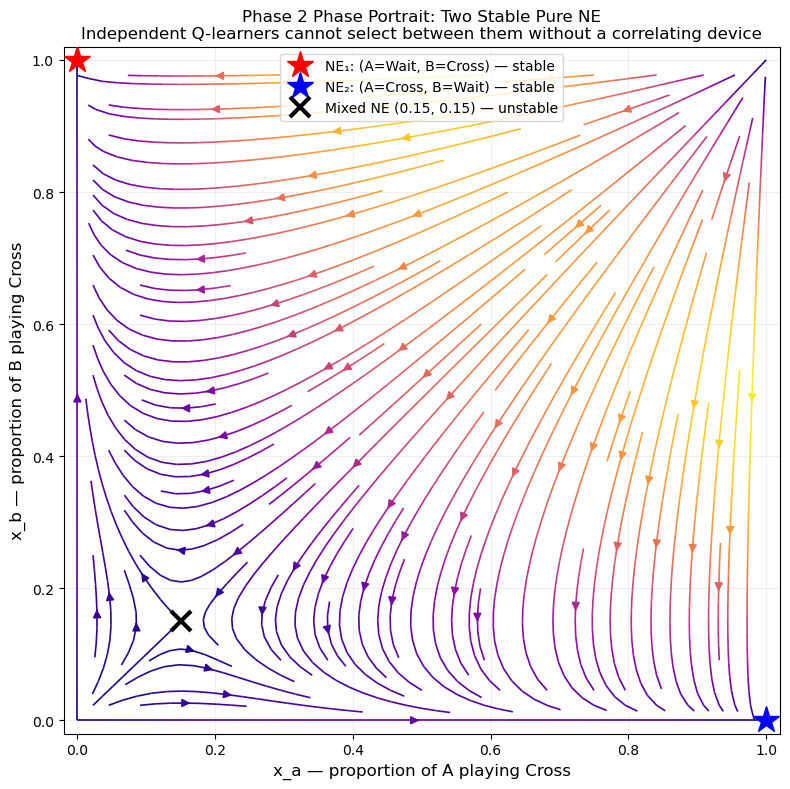

In [57]:
# ─────────────────────────────────────────────────────────────────────────
# Phase 2 phase portrait (vector field / streamplot)
# ─────────────────────────────────────────────────────────────────────────
# Shows the two stable pure NE as attractors and the unstable mixed NE
# as a repeller / saddle point in the (x_a, x_b) strategy space.

GRID_RESOLUTION = 25   # number of points per axis for the vector field

x_a_grid, x_b_grid = np.meshgrid(
    np.linspace(0, 1, GRID_RESOLUTION),
    np.linspace(0, 1, GRID_RESOLUTION),
)
u = np.zeros_like(x_a_grid)   # dx_a/dt at each grid point
v = np.zeros_like(x_b_grid)   # dx_b/dt at each grid point

for i in range(GRID_RESOLUTION):
    for j in range(GRID_RESOLUTION):
        u_val, v_val = replicator_phase2((float(x_a_grid[i, j]), float(x_b_grid[i, j])), 0.0)
        u[i, j] = u_val
        v[i, j] = v_val

fig_pp, ax_pp = plt.subplots(figsize=(8, 8))
ax_pp.streamplot(
    x=x_a_grid, y=x_b_grid, u=u, v=v,
    color=np.sqrt(u**2 + v**2),   # colour by vector magnitude
    cmap='plasma', linewidth=1.2, density=1.5, arrowsize=1.2,
)

# Equilibrium markers
ax_pp.plot(0, 1, 'r*', markersize=20, zorder=5, label='NE₁: (A=Wait, B=Cross) — stable')
ax_pp.plot(1, 0, 'b*', markersize=20, zorder=5, label='NE₂: (A=Cross, B=Wait) — stable')
ax_pp.plot(
    _MIXED_NE, _MIXED_NE, 'kx',
    markersize=14, markeredgewidth=3, zorder=5,
    label=f'Mixed NE ({_MIXED_NE:.2f}, {_MIXED_NE:.2f}) — unstable',
)

ax_pp.set_xlim(-0.02, 1.02)
ax_pp.set_ylim(-0.02, 1.02)
ax_pp.set_xlabel('x_a — proportion of A playing Cross', fontsize=12)
ax_pp.set_ylabel('x_b — proportion of B playing Cross', fontsize=12)
ax_pp.set_title(
    'Phase 2 Phase Portrait: Two Stable Pure NE\n'
    'Independent Q-learners cannot select between them without a correlating device',
    fontsize=12,
)
ax_pp.legend(fontsize=10, loc='upper center')
ax_pp.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Task 4 — Theoretical Justification

> **Phase 1** is an **asymmetric game**. Agent A's water hazard makes **Wait a dominant strategy** (cost -3 vs expected -10) for every opponent strategy. Dominant strategy elimination yields a **unique Nash Equilibrium** (A = Wait, B = Cross). This fixes A's policy early, making B's environment stationary, satisfying Q-learning's convergence guarantee. Phase 1 is solvable by independent learners.
>
> **Phase 2** removes the asymmetry, producing a **symmetric anti-coordination game** with two stable pure Nash Equilibria and one unstable mixed NE at x = 0.15. No dominant strategy exists; neither agent's policy stabilises first. Each agent's learning target shifts as the other adapts, creating **non-stationarity** in the MDP sense. Resolving which pure NE to play requires a **correlated equilibrium**: a shared signal assigning crossing roles. Independent Q-learners maintain separate Q-tables with no coordination channel and cannot implement this asymmetric role assignment. Robert is wrong and Sarah is right.

## 8. Conclusion

This simulation confirms Sarah's theory across all four tasks.

In Phase 1, the water hazard asymmetry acts as a natural coordination mechanism: Agent A's dominant strategy eliminates the need for explicit communication, producing a unique Nash Equilibrium that independent Q-learning reliably finds. Both collision rate and hazard rate converge to zero and hold stable across 8,400 episodes, providing empirical proof of the traffic-light strategy.

In Phase 2, removing the asymmetry transforms the game into a symmetric anti-coordination problem with two competing equilibria. Independent Q-learners cannot select between them without a correlated equilibrium mechanism, producing the persistent oscillating collision rates confirmed in training and predicted by replicator dynamics.

The HD experiment further shows that the coordination failure is most acute at intermediate step costs, where crossing is worth attempting but expensive enough to create conflict, revealing a non-monotonic relationship between penalty magnitude and coordination difficulty.

The game-theoretic analysis confirms that the structural difference between Phase 1 (unique equilibrium, dominant strategy) and Phase 2 (multiple equilibria, no dominant strategy) is the root cause of the difference in learning outcomes. Robert is wrong. Sarah is right.